El servicio de venta de autos usados Rusty Bargain está desarrollando una aplicación para atraer nuevos clientes. Gracias a esa app, puedes averiguar rápidamente el valor de mercado de tu coche. Tienes acceso al historial: especificaciones técnicas, versiones de equipamiento y precios. Tienes que crear un modelo que determine el valor de mercado.
A Rusty Bargain le interesa:
- la calidad de la predicción;
- la velocidad de la predicción;
- el tiempo requerido para el entrenamiento

In [77]:
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from category_encoders import TargetEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Librerías importadas correctamente')

Librerías importadas correctamente


In [78]:
# Funciones
def calculate_rmse(y_real, y_pred):
    return np.sqrt(mean_squared_error(y_real, y_pred))

def create_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

def create_target_encoders():
    return TargetEncoder()

def show_sep(title):
    print('\n' + '=' * 70)
    print(title)
    print('=' * 70)

## Preparación de datos

### 1.1 Cargar los datos

In [79]:
path = 'datasets/car_data.csv'

df = pd.read_csv(path)

print('Dataset cargado correctamente')
print('Filas y columnas: ', df.shape)

display(df.head())

Dataset cargado correctamente
Filas y columnas:  (354369, 16)


,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


In [80]:
print('Información general del dataset')
df.info()

Información general del dataset
<class 'pandas.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   DateCrawled        354369 non-null  str  
 1   Price              354369 non-null  int64
 2   VehicleType        316879 non-null  str  
 3   RegistrationYear   354369 non-null  int64
 4   Gearbox            334536 non-null  str  
 5   Power              354369 non-null  int64
 6   Model              334664 non-null  str  
 7   Mileage            354369 non-null  int64
 8   RegistrationMonth  354369 non-null  int64
 9   FuelType           321474 non-null  str  
 10  Brand              354369 non-null  str  
 11  NotRepaired        283215 non-null  str  
 12  DateCreated        354369 non-null  str  
 13  NumberOfPictures   354369 non-null  int64
 14  PostalCode         354369 non-null  int64
 15  LastSeen           354369 non-null  str  
dtypes: int64(7), str(

### 1.2 Verificación de datos nulos

In [81]:
nulls = pd.DataFrame({
    'nulls': df.isna().sum(),
    'percent': df.isna().mean() * 100
}).sort_values('nulls', ascending=False)

display(nulls)

,nulls,percent
NotRepaired,71154,20.08
VehicleType,37490,10.58
FuelType,32895,9.28
Gearbox,19833,5.60
Model,19705,5.56
DateCrawled,0,0.00
Price,0,0.00
RegistrationYear,0,0.00
Power,0,0.00
Mileage,0,0.00


### 1.3 Revisión de la variable objetivo

count   354,369.00
mean      4,416.66
std       4,514.16
min           0.00
25%       1,050.00
50%       2,700.00
75%       6,400.00
max      20,000.00
Name: Price, dtype: float64

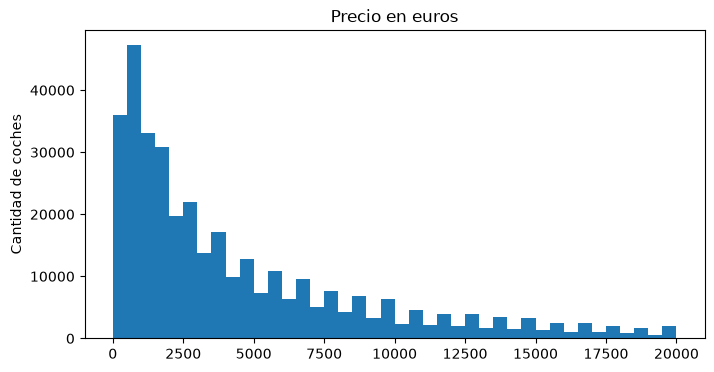

In [82]:
display(df['Price'].describe())

df['Price'].plot(
    kind='hist',
    bins=40,
    figsize=(8, 4),
    title='Distribución de precios'
)
plt.title('Precio en euros')
plt.ylabel('Cantidad de coches')
plt.show()

In [83]:
price_zero = (df['Price'] <= 0).sum()
print('Registros con Price <= 0:', price_zero)
print('Porcentaje:', round(price_zero / len(df) * 100, 2), '%')

Registros con Price <= 0: 10772
Porcentaje: 3.04 %


Al revisar la variable objetivo puedo ver que hay un 3.4% de valores menor o igual a 0, es algo que hay que tomar en cuenta por que no tiene logica que exista autos de valor 0 euros.

### 1.4 Crear una copia limipia

In [84]:
df_clean = df.copy()

initial_rows = len(df_clean)
print('Filas iniciales:', initial_rows)

filter_price = df_clean['Price'] > 0
filter_year = df_clean['RegistrationYear'].between(1980, 2025)
filter_power = df_clean['Power'].between(30, 500)

df_clean = df_clean[
    filter_price &
    filter_year &
    filter_power
].copy()

final_rows = len(df_clean)
deleted_rows = initial_rows - final_rows

print('Filas después de filtros:', final_rows)
print('Filas eliminadas:', deleted_rows)
print('Porcentaje eliminado:', round(deleted_rows / initial_rows * 100, 2), '%')

Filas iniciales: 354369
Filas después de filtros: 303940
Filas eliminadas: 50429
Porcentaje eliminado: 14.23 %


In [85]:
# Columnas categoricas que pueden tener nulos.
# Usamos una etiqueta explicita para que el modelo no pieda esas filas.
cat_columns_with_nulls = [
    'VehicleType',
    'Gearbox',
    'Model',
    'FuelType',
    'NotRepaired'
]

for column in cat_columns_with_nulls:
    df_clean[column] = df_clean[column].fillna('unknown')

display(df_clean.isna().sum().to_frame('null'))

,null
DateCrawled,0
Price,0
VehicleType,0
RegistrationYear,0
Gearbox,0
Power,0
Model,0
Mileage,0
RegistrationMonth,0
FuelType,0


In [86]:
# Comparar distribución del precio antés y depués de la limipieza.
# Esto ayudara a confirma que no destruimos la estructura del problema.}

price_comparison = pd.DataFrame({
    'original': df['Price'].describe(),
    'limpio': df_clean['Price'].describe()
})

display(price_comparison)

,original,limpio
count,"354,369.00","303,940.00"
mean,"4,416.66","4,788.36"
std,"4,514.16","4,571.56"
min,0.00,1.00
25%,"1,050.00","1,300.00"
50%,"2,700.00","3,083.50"
75%,"6,400.00","6,900.00"
max,"20,000.00","20,000.00"


Se corrigieron algunos detalles con el DataFrame
- Se filtro los registros con el target menor o igual a 0
- también se selecciono aquellos registros autos que fueron registrados entre 1980 y 2025
- también se selecciono aquellos que tienen una potencia entre 30 y 500.
- También se relleno los valores ausentes con una la etiqueta 'unknown'.

### 1.5 Seleccionar columnas para modelar

In [87]:
# Variable objetivo
y = df_clean['Price']

features = [
    'VehicleType',
    'RegistrationYear',
    'Gearbox',
    'Power',
    'Model',
    'Mileage',
    'RegistrationMonth',
    'FuelType',
    'Brand',
    'NotRepaired'
]

X = df_clean[features]

print('Shape de X:', X.shape)
print('Shape de y:', y.shape)

display(X.head())

Shape de X: (303940, 10)
Shape de y: (303940,)


,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired
1,coupe,2011,manual,190,unknown,125000,5,gasoline,audi,yes
2,suv,2004,auto,163,grand,125000,8,gasoline,jeep,unknown
3,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no
4,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no
5,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes


In [88]:
# Separar columnas numéricas y categoricas.
# Esto es necesario porque cada tipo de columna requiere un trantamiento distinto.

numerical_columns = [
    'RegistrationYear',
    'Power',
    'Mileage',
    'RegistrationMonth'
]

categorical_columns = [
    'VehicleType',
    'Gearbox',
    'Model',
    'FuelType',
    'Brand',
    'NotRepaired'
]

print('Columnas numéricas:', numerical_columns)
print('Columnas categoricas:', categorical_columns)

Columnas numéricas: ['RegistrationYear', 'Power', 'Mileage', 'RegistrationMonth']
Columnas categoricas: ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']


Se obtuvo la variable objetivo y las características. También se separarón los nombre de las features en numerica y categorica por que algunos frameworks de boosting lo requeriran para inicializar el modelo.

### 1.6 Train/test split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (227955, 10)
X_test: (75985, 10)
y_train: (227955,)
y_test: (75985,)


Se obtuvieron los conjuntos de entrenamiento y test en proporciones 75%, 25% respectivamente.

### 1.7 Convertir a category

In [90]:
# Convertir las columnas categoricas a category

categorical_columns_dic = {col: 'category' for col in categorical_columns}

X_train_cat = X_train.astype(categorical_columns_dic)
X_test_cat = X_test.astype(categorical_columns_dic)

display(X_train_cat.head())
X_train_cat.info()

,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired
160978,wagon,2002,manual,192,5er,150000,6,petrol,bmw,no
93677,small,2002,manual,103,stilo,150000,2,petrol,fiat,yes
137005,small,2006,manual,69,ibiza,150000,7,petrol,seat,no
1022,unknown,2016,manual,177,1er,150000,7,unknown,bmw,no
314169,sedan,2009,manual,125,leon,90000,10,petrol,seat,no


<class 'pandas.DataFrame'>
Index: 227955 entries, 160978 to 142205
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   VehicleType        227955 non-null  category
 1   RegistrationYear   227955 non-null  int64   
 2   Gearbox            227955 non-null  category
 3   Power              227955 non-null  int64   
 4   Model              227955 non-null  category
 5   Mileage            227955 non-null  int64   
 6   RegistrationMonth  227955 non-null  int64   
 7   FuelType           227955 non-null  category
 8   Brand              227955 non-null  category
 9   NotRepaired        227955 non-null  category
dtypes: category(6), int64(4)
memory usage: 10.2 MB


Convertir las columnas categoricas en tipo de datos "category" para los modelos boosting.
Ya que la mayoria funcionan con este tipo de dato para la características categoricas.

### 1.8 Preprocesamiento con ColumnTranformer

In [91]:
# Preprocesamiento numérico:
# StandardScaler centra y escala las variables numéricas.
# Esto ayuda especialmente a modelos lineales.

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Preprocesamiento categorico:
# OneHotEncoder convierte categorias en columnas 0/1.
# handle_unknow='ignore' evita errores si en test aparece una categoria no vista en train.

categorical_transformer = Pipeline(steps=[
    ('target', create_target_encoders())
])

# ColumnTransformer combina ambos tratamientos.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ]
)

print('Preprocesador creado correctamente')

Preprocesador creado correctamente


Se crearon los preprocesadores, requeridos por los modelos simples.

## Entrenamiento del modelo 

### 2.1 Función para entrenar y evaluar modelos.

In [92]:
def train_and_evaluate(
        name, 
        model, 
        X_train=X_train, 
        X_test=X_test, 
        y_train=y_train, 
        y_test=y_test,
        use_preprocessor=True):
    """
    Entrenar un modelo dentro de un Pipeline y calcular métrica RMSE.

    Parametros
    ----------
    name : str
        Nombre legible del enperimento.
    modelo : modelo
        Modelo que queremos probar
    X_train, X_test, y_train, y_test : pandas DataFrame / Series
        Datos ya separados en entrenamiento y prueba.
    use_preprocessor : boolean
        Usar o no preprocesador propio o delegar a los modelos (boostings)

    Retorna
    ---------
    dict
        Diccionario con nombre del modelo, RMSE, tiempos y pipeline entrenado.
    """

    if use_preprocessor:
    # 1. Crear pipeline: primero preprocesa, luego entrena el modelo.
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ])
    else:
        pipeline = Pipeline(steps=[
            ('model', model)
        ])

    # 2. Medir tiempo de entrenamiento.
    start_train = time.perf_counter()
    pipeline.fit(X_train, y_train)
    end_train = time.perf_counter()

    # 3. Medir tiempo de predicción.
    start_pred = time.perf_counter()
    predictions = pipeline.predict(X_test)
    end_pred = time.perf_counter()

    # 4. Calcular error.
    rmse = calculate_rmse(y_test, predictions)

    # 5. Guardar resultados.
    results = {
        'model': name,
        'rmse': rmse,
        'train_time_sec': end_train - start_train,
        'pred_time_sec': end_pred - start_pred,
        'pipeline': pipeline
    }

    return results

### 2.2 Modelo de cordura: Regresión lineal

Si un modelo más complejo funciona peor que la regresión lineal, ser debe revisar antes de confiar en el resultado.

In [93]:
linear_result = train_and_evaluate(
    name='Regresión Lineal',
    model=LinearRegression()
)

result_linear_summary = {k: v for k, v in linear_result.items() if k != 'pipeline'}
display(pd.DataFrame([result_linear_summary]))

,model,rmse,train_time_sec,pred_time_sec
0,Regresión Lineal,"2,665.62",0.29,0.02


Primer modelo Regresión Lineal como modelo base.

### 2.3 Árbol de decisión

In [94]:
tree_results = []

for depth in [5, 6, 7, 8, 9, 10]:
    result = train_and_evaluate(
        name=f'Árbol de decisión depth={depth}',
        model=DecisionTreeRegressor(max_depth=depth, random_state=42)
    )
    tree_results.append(result)

tree_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'pipeline'}
    for r in tree_results
])

display(tree_summary)

,model,rmse,train_time_sec,pred_time_sec
0,Árbol de decisión depth=5,"2,402.26",0.41,0.03
1,Árbol de decisión depth=6,"2,237.39",0.42,0.02
2,Árbol de decisión depth=7,"2,105.88",0.46,0.03
3,Árbol de decisión depth=8,"2,005.44",0.47,0.03
4,Árbol de decisión depth=9,"1,935.69",0.49,0.03
5,Árbol de decisión depth=10,"1,882.19",0.51,0.03


### 2.4 Bosque aleatorio

In [95]:
forest_results = []

forest_settings = [
    {'n_estimators': 20, 'max_depth': 6},
    {'n_estimators': 30, 'max_depth': 8},
    {'n_estimators': 60, 'max_depth': 12}
]

for config in forest_settings:
    name = f"Bosque aleatorio trees={config['n_estimators']} depth={config['max_depth']}"
    result = train_and_evaluate(
        name=name,
        model=RandomForestRegressor(
            n_estimators=config['n_estimators'],
            max_depth=config['max_depth'],
            random_state=42,
            n_jobs=-1
        )
    )
    forest_results.append(result)

forest_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'pipeline'}
    for r in forest_results
])

display(forest_summary)

,model,rmse,train_time_sec,pred_time_sec
0,Bosque aleatorio trees=20 depth=6,"2,166.11",0.65,0.04
1,Bosque aleatorio trees=30 depth=8,"1,922.22",0.84,0.04
2,Bosque aleatorio trees=60 depth=12,"1,662.58",1.58,0.06


### 2.5 Boosting simple

In [96]:
boosting_results = []

boosting_settings = [
    {'n_estimators': 60, 'learning_rate': 0.08, 'max_depth': 3},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3}
]

for config in boosting_settings:
    name = f"Gradient Boosting n={config['n_estimators']} lr={config['learning_rate']}"
    result = train_and_evaluate(
        name=name,
        model=GradientBoostingRegressor(
            n_estimators=config['n_estimators'],
            learning_rate=config['learning_rate'],
            max_depth=config['max_depth'],
            random_state=42
        )
    )
    boosting_results.append(result)

boosting_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'pipeline'}
    for r in boosting_results
])

display(boosting_summary)

,model,rmse,train_time_sec,pred_time_sec
0,Gradient Boosting n=60 lr=0.08,"1,960.14",5.46,0.06
1,Gradient Boosting n=100 lr=0.05,"1,947.49",8.93,0.08


### 2.6 CatBoost

In [97]:
catboost_results = []

catboost_settings = [
    {'iterations': 1100, 'learning_rate': 0.06, 'depth':8},
    {'iterations': 1000, 'learning_rate': 0.05, 'depth':6},
    {'iterations': 900, 'learning_rate': 0.04, 'depth':5}
]
for config in catboost_settings:
    result = train_and_evaluate(
        # DataFrame con features category
        X_train=X_train_cat,
        X_test=X_test_cat,
        name=f"CatBoost iterations={config['iterations']} learning={config['learning_rate']} depth={config['depth']}",
        model=CatBoostRegressor(
            iterations=config['iterations'],
            learning_rate=config['learning_rate'],
            depth=config['depth'],
            # dejar que CatBoost trate las columnas categoricas
            cat_features=categorical_columns,
            verbose=False
        ),
        # delegar el preprocesamiento al framework
        use_preprocessor=False
    )

    catboost_results.append(result)

catboost_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'pipeline'}
    for r in catboost_results
])

display(catboost_summary)

,model,rmse,train_time_sec,pred_time_sec
0,CatBoost iterations=1100 learning=0.06 depth=8,"1,542.01",25.88,0.03
1,CatBoost iterations=1000 learning=0.05 depth=6,"1,599.01",17.06,0.02
2,CatBoost iterations=900 learning=0.04 depth=5,"1,651.59",12.95,0.02


### 2.7 XGBoost

In [98]:
xgboost_results = []

xgboost_settings = [
    {
        'n_estimators': 500, 
        'learning_rate': 0.1, 
        'max_depth': 5, 
        'subsample': 0.8, 
        'colsample_bytree': 0.8
    },
    {
        'n_estimators': 1000, 
        'learning_rate': 0.05, 
        'max_depth': 4, 
        'subsample': 0.7, 
        'colsample_bytree': 0.7
    },
    {
        'n_estimators': 1200, 
        'learning_rate': 0.03, 
        'max_depth': 7, 
        'subsample': 0.8, 
        'colsample_bytree': 0.8
    },
    {
        'n_estimators': 1800, 
        'learning_rate': 0.01, 
        'max_depth': 6, 
        'subsample': 0.9, 
        'colsample_bytree': 0.8
    }
]

for config in xgboost_settings:
    result = train_and_evaluate(
        # Dataframe con features category
        X_train=X_train_cat,
        X_test=X_test_cat,
        name=f"XGBoost n_estimators={config['n_estimators']} learning_rate={config['learning_rate']} max_depth={config['max_depth']} subsample={config['subsample']} colsample_bytree={config['colsample_bytree']}",
        model=XGBRegressor(
            n_estimators=config['n_estimators'],
            learning_rate=config['learning_rate'],
            max_depth=config['max_depth'],
            subsample=config['subsample'],
            colsample_bytree=config['colsample_bytree'],
            enable_categorical=True
        ),
        # delegando el preprocesamiento al framework
        use_preprocessor=False
    )

    xgboost_results.append(result)

xgboost_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'pipeline'}
    for r in xgboost_results
])

display(xgboost_summary)

,model,rmse,train_time_sec,pred_time_sec
0,XGBoost n_estimators=500 learning_rate=0.1 max...,"1,549.92",1.40,0.05
1,XGBoost n_estimators=1000 learning_rate=0.05 m...,"1,589.48",2.26,0.08
2,XGBoost n_estimators=1200 learning_rate=0.03 m...,"1,491.36",4.54,0.20
3,XGBoost n_estimators=1800 learning_rate=0.01 m...,"1,542.57",5.71,0.25


### 2.8 LightGBM

In [99]:
lightgbm_results = []

lightgbm_settings = [
    {
        'n_estimators': 600,
        'learning_rate': 0.1,
        'num_leaves': 31,          
        'max_depth': 6,
        'min_child_samples': 20
    },
    {
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'num_leaves': 15,          
        'max_depth': 4,
        'min_child_samples': 30
    },
    {
        'n_estimators': 1500,
        'learning_rate': 0.03,
        'num_leaves': 63,         
        'max_depth': 8,
        'min_child_samples': 25
    },
    {
        'n_estimators': 2000,
        'learning_rate': 0.01,
        'num_leaves': 127,         
        'max_depth': -1,           
        'min_child_samples': 50    
    }
]

for config in lightgbm_settings:
    result = train_and_evaluate(
        # DataFrames con columnas category
        X_train=X_train_cat,
        X_test=X_test_cat,
        name=f"LightGBM n_estimators={config['n_estimators']} learning_rate={config['learning_rate']} num_leaves={config['num_leaves']} max_depth={config['max_depth']} min_child_samples={config['min_child_samples']}",
        model=LGBMRegressor(
            n_estimators=config['n_estimators'],
            learning_rate=config['learning_rate'],
            num_leaves=config['num_leaves'],
            max_depth=config['max_depth'],
            min_child_sample=config['min_child_samples'],
            random_state=42,
            verbose=-1
        ),
        # delegando el preprocesamiento al framework
        use_preprocessor=False
    )
    lightgbm_results.append(result)

lightgbm_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'pipeline'}
    for r in lightgbm_results
])

display(lightgbm_summary)

,model,rmse,train_time_sec,pred_time_sec
0,LightGBM n_estimators=600 learning_rate=0.1 nu...,"1,522.90",3.61,0.13
1,LightGBM n_estimators=1000 learning_rate=0.05 ...,"1,575.75",3.01,0.17
2,LightGBM n_estimators=1500 learning_rate=0.03 ...,"1,501.62",17.84,0.54
3,LightGBM n_estimators=2000 learning_rate=0.01 ...,"1,488.25",56.15,1.00


Se probaron modelos simples y modelos basados en boostings. 

## Análisis del modelo

### 3.1 Comparar calidad y velocidad

In [100]:
results = [
    linear_result,
    *forest_results,
    *tree_results,
    *boosting_results,
    *catboost_results,
    *xgboost_results,
    *lightgbm_results,
]

comparison = pd.DataFrame([
    {k: v for k, v in result.items() if k != 'pipeline'}
    for result in results
]).sort_values('rmse')

# Redondear solo para mostrar
comparative_table = comparison.copy()
comparative_table['rmse'] = comparative_table['rmse'].round(2)
comparative_table['train_time_se'] = comparative_table['train_time_sec'].round(4)
comparative_table['pred_time_sec'] = comparative_table['pred_time_sec'].round(4)

display(comparative_table)

,model,rmse,train_time_sec,pred_time_sec,train_time_se
22,LightGBM n_estimators=2000 learning_rate=0.01 ...,"1,488.25",56.15,1.00,56.15
17,XGBoost n_estimators=1200 learning_rate=0.03 m...,"1,491.36",4.54,0.20,4.54
21,LightGBM n_estimators=1500 learning_rate=0.03 ...,"1,501.62",17.84,0.54,17.84
19,LightGBM n_estimators=600 learning_rate=0.1 nu...,"1,522.90",3.61,0.13,3.61
12,CatBoost iterations=1100 learning=0.06 depth=8,"1,542.01",25.88,0.03,25.88
18,XGBoost n_estimators=1800 learning_rate=0.01 m...,"1,542.57",5.71,0.25,5.71
15,XGBoost n_estimators=500 learning_rate=0.1 max...,"1,549.92",1.40,0.05,1.40
20,LightGBM n_estimators=1000 learning_rate=0.05 ...,"1,575.75",3.01,0.17,3.01
16,XGBoost n_estimators=1000 learning_rate=0.05 m...,"1,589.48",2.26,0.08,2.26
13,CatBoost iterations=1000 learning=0.05 depth=6,"1,599.01",17.06,0.02,17.06


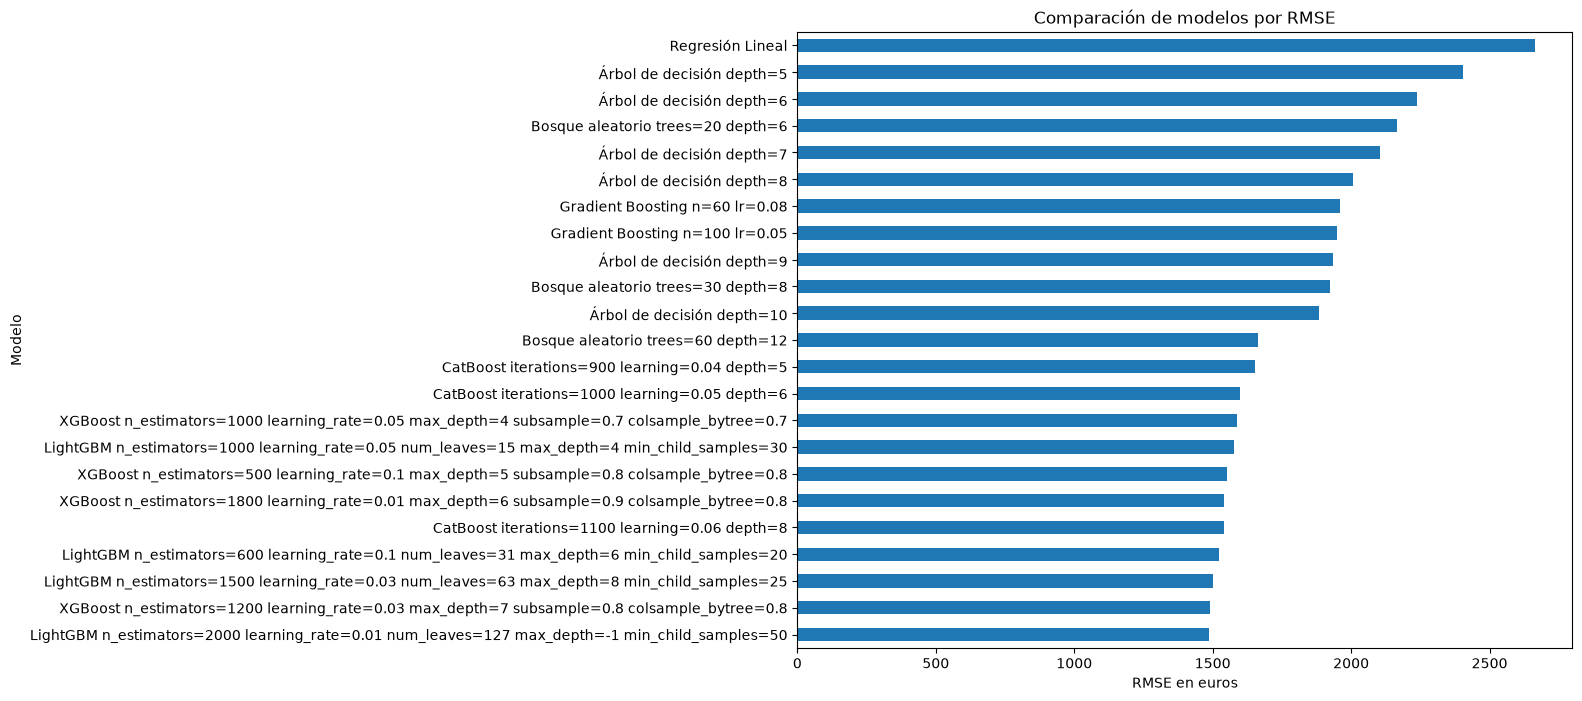

In [101]:
# Grafica 1: calidad del modelo.
# Menor RMSE es mejor.

comparative_table.set_index('model')['rmse'].sort_values().plot(
    kind='barh',
    figsize=(10, 8),
    title='Comparación de modelos por RMSE'
)
plt.xlabel('RMSE en euros')
plt.ylabel('Modelo')
plt.show()

Claramente la regresión lineal tiene un RMSE más alto, indicandonos que los demás modelos son mejores que un modelo base.

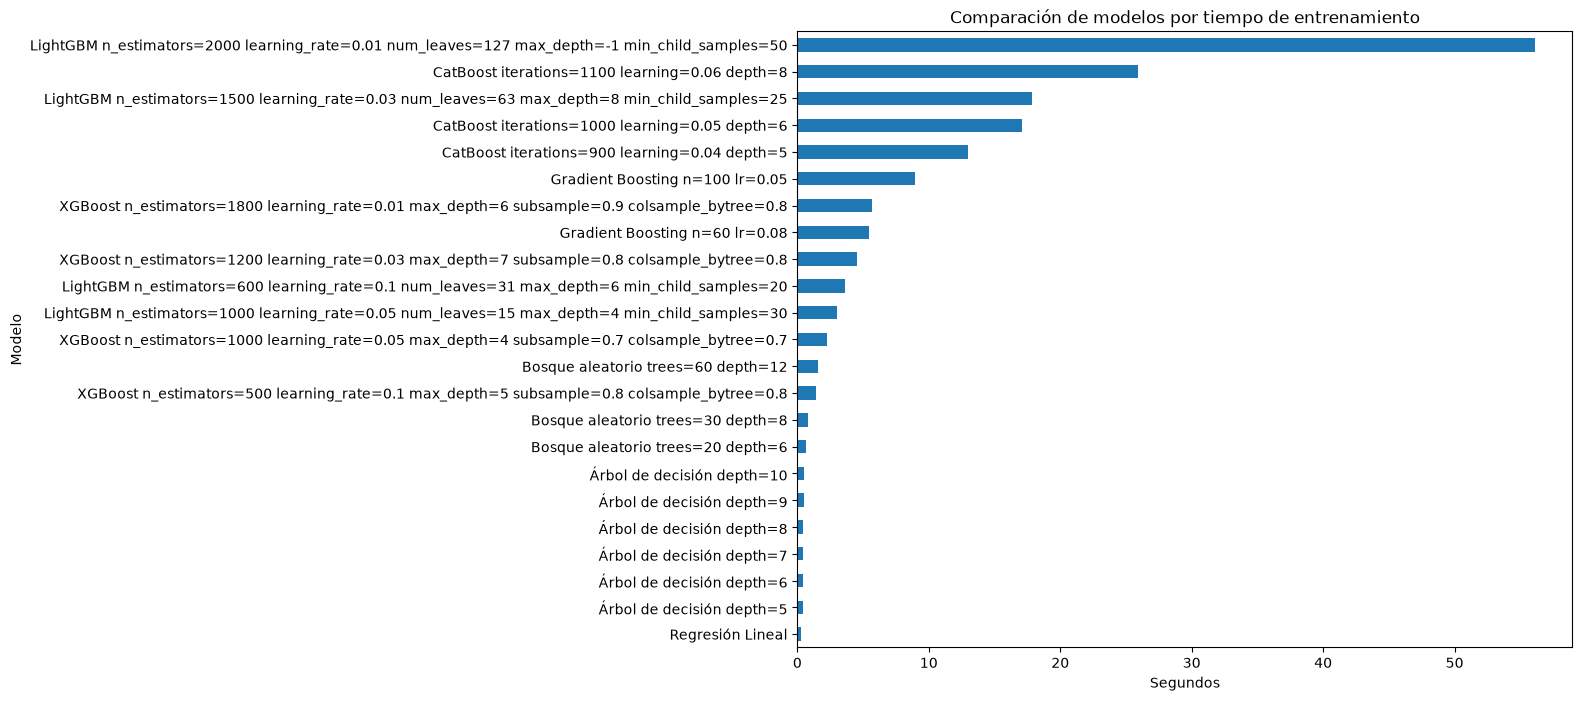

In [102]:
# Grafica 2: costo de entrenamiento.
# Esta grafica ayuda a discutir el trade-off entre calidad y tiempo.

comparative_table.set_index('model')['train_time_sec'].sort_values().plot(
    kind='barh',
    figsize=(10, 8),
    title='Comparación de modelos por tiempo de entrenamiento'
)
plt.xlabel('Segundos')
plt.ylabel('Modelo')
plt.show()

Es sorprendente la diferencia entre el tiempo de entrenamiento, mientras unos se entrenaron en menos de 1 segundo hay uno que le tomo 1 minuto.

### 3.2 Recomendación para el negocio

In [103]:
best_model = comparative_table.loc[15]

print('Recomendación final')
print()
print(
    f"Para una primera version de la app, recomendaria el modelo "
    f"'{best_model['model']}'. En esta prueba obtuvo un RMSE aproximado de "
    f"{best_model['rmse']} euros, con un tiempo de entrenamiento de "
    f"{best_model['train_time_sec']} segundos y un tiempo de prediccion de "
    f"{best_model['pred_time_sec']} segundos sobre el conjunto de prueba. "
    f"Siendo el más eficiente, ya que el tiempo de entrenamiento fue bajo en comparación "
    f"con los otros modelos, además obtiene uno de los rmse más bajos."
)

Recomendación final

Para una primera version de la app, recomendaria el modelo 'XGBoost n_estimators=500 learning_rate=0.1 max_depth=5 subsample=0.8 colsample_bytree=0.8'. En esta prueba obtuvo un RMSE aproximado de 1549.92 euros, con un tiempo de entrenamiento de 1.4047564169995894 segundos y un tiempo de prediccion de 0.0518 segundos sobre el conjunto de prueba. Siendo el más eficiente, ya que el tiempo de entrenamiento fue bajo en comparación con los otros modelos, además obtiene uno de los rmse más bajos.


# Lista de control

Escribe 'x' para verificar. Luego presiona Shift+Enter

- [x]  Jupyter Notebook está abierto
- [x]  El código no tiene errores- [x]  Las celdas con el código han sido colocadas en orden de ejecución- [x]  Los datos han sido descargados y preparados- [x]  Los modelos han sido entrenados
- [x]  Se realizó el análisis de velocidad y calidad de los modelos